In [12]:
import sys
import os
import torch
import urllib.request
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))

from attention import simple_self_attention, ScaledDotProductAttention


# ============================================================
# Entrada simulada
# ============================================================

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89],  # Your
        [0.55, 0.87, 0.66],  # journey
        [0.57, 0.85, 0.64],  # starts
        [0.22, 0.58, 0.33],  # with
        [0.77, 0.25, 0.10],  # one
        [0.05, 0.80, 0.55]   # step
    ]
)

print("\nEntrada:")
print(inputs)
print("Formato:", inputs.shape)


# ============================================================
# Teste 1 - Self-Attention Simplificado
# ============================================================

print("\n" + "=" * 60)
print("TESTE 1: Self-Attention Simplificado")
print("=" * 60)

context_vecs_simple, weights_simple = simple_self_attention(inputs)

print("\nFormato do Vetor de Contexto:")
print(context_vecs_simple.shape)

print("\nVetores de Contexto:")
print(context_vecs_simple)

print("\nPesos de Atenção:")
print(weights_simple)

print("\nSoma dos pesos da primeira linha:")
print(weights_simple[0].sum().item())



Entrada:
tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
Formato: torch.Size([6, 3])

TESTE 1: Self-Attention Simplificado

Formato do Vetor de Contexto:
torch.Size([6, 3])

Vetores de Contexto:
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

Pesos de Atenção:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

Soma dos pesos da primeira linha:
1.0000001192092896


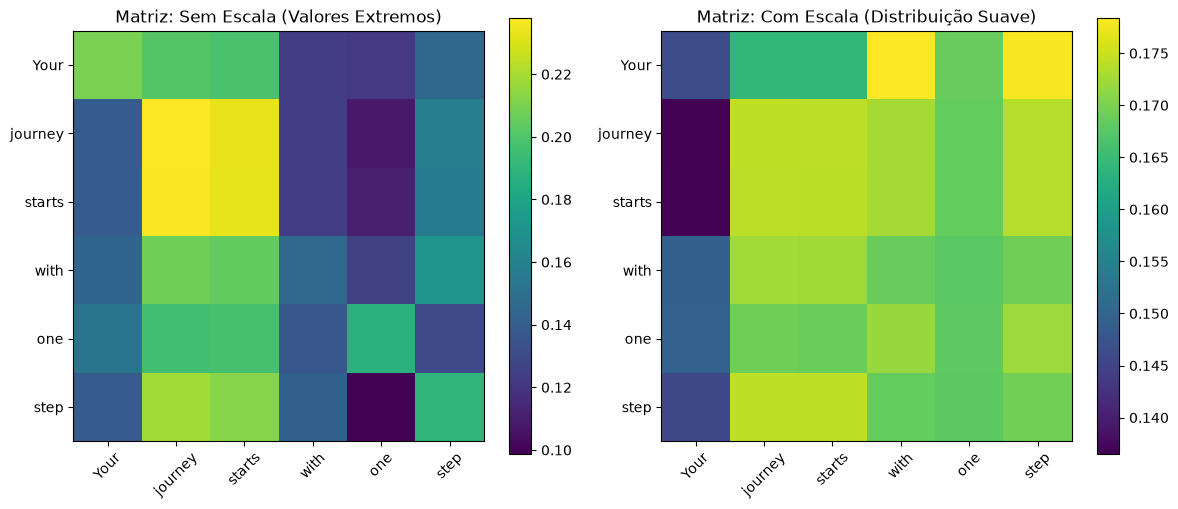

Observação: Sem escala, o softmax tende a gerar valores muito próximos de 1 em uma única palavra, anulando os gradientes. Com a escala, a atenção é melhor distribuída.


In [13]:
import sys
import torch
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from attention import simple_self_attention, ScaledDotProductAttention

# Dados de entrada
inputs = torch.tensor([
    [0.43, 0.15, 0.89], [0.55, 0.87, 0.66], [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33], [0.77, 0.25, 0.10], [0.05, 0.80, 0.55]
])
palavras = ["Your", "journey", "starts", "with", "one", "step"]

# 1. Sem Escala (Self-Attention Simplificado)
_, weights_unscaled = simple_self_attention(inputs)

# 2. Com Escala (Scaled Dot-Product Attention)
torch.manual_seed(123)
attention_module = ScaledDotProductAttention(d_in=3, d_out=3)
_, weights_scaled = attention_module(inputs)

# 3. Visualização (Heatmap)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Sem Escala
im1 = axes[0].imshow(weights_unscaled.detach().numpy(), cmap='viridis')
axes[0].set_title("Matriz: Sem Escala (Valores Extremos)")
axes[0].set_xticks(range(len(palavras))); axes[0].set_xticklabels(palavras, rotation=45)
axes[0].set_yticks(range(len(palavras))); axes[0].set_yticklabels(palavras)
fig.colorbar(im1, ax=axes[0])

# Plot Com Escala
im2 = axes[1].imshow(weights_scaled.detach().numpy(), cmap='viridis')
axes[1].set_title("Matriz: Com Escala (Distribuição Suave)")
axes[1].set_xticks(range(len(palavras))); axes[1].set_xticklabels(palavras, rotation=45)
axes[1].set_yticks(range(len(palavras))); axes[1].set_yticklabels(palavras)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Observação: Sem escala, o softmax tende a gerar valores muito próximos de 1 em uma única palavra, anulando os gradientes. Com a escala, a atenção é melhor distribuída.")

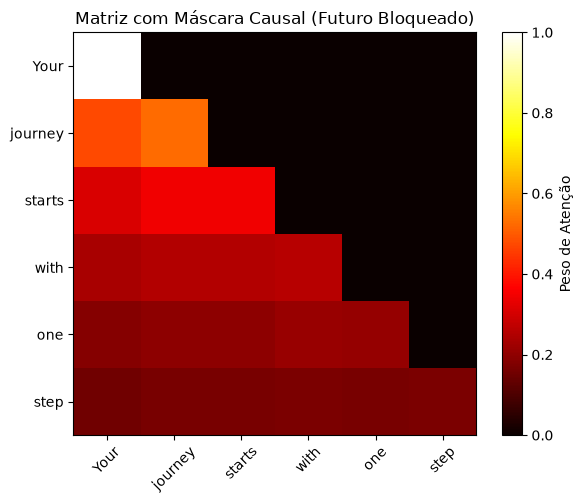

Observação: O triângulo superior preto (peso 0) prova que tokens não 'enxergam' palavras à frente na sequência.


In [14]:
import sys
import torch
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from attention import CausalAttention

# Dados de entrada (Adicionando dimensão de batch)
inputs = torch.tensor([
    [0.43, 0.15, 0.89], [0.55, 0.87, 0.66], [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33], [0.77, 0.25, 0.10], [0.05, 0.80, 0.55]
])
batch = inputs.unsqueeze(0) # Formato [1, 6, 3]
palavras = ["Your", "journey", "starts", "with", "one", "step"]

# Instancia a Causal Attention
context_length = batch.shape[1]
causal_attention = CausalAttention(d_in=3, d_out=3, context_length=context_length, dropout=0.0)

# Para visualizar a máscara agindo nos pesos, vamos simular a matemática interna:
keys = causal_attention.W_key(batch)
queries = causal_attention.W_query(batch)
attn_scores = queries @ keys.transpose(1, 2)

# Aplica a máscara (Triângulo superior vira -inf)
mask_bool = causal_attention.mask.bool()[:context_length, :context_length]
attn_scores.masked_fill_(mask_bool, -torch.inf)

# Softmax
attn_weights_causal = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

# Visualização
plt.figure(figsize=(6, 5))
plt.imshow(attn_weights_causal[0].detach().numpy(), cmap='hot')
plt.title("Matriz com Máscara Causal (Futuro Bloqueado)")
plt.xticks(range(len(palavras)), palavras, rotation=45)
plt.yticks(range(len(palavras)), palavras)
plt.colorbar(label='Peso de Atenção')
plt.tight_layout()
plt.show()

print("Observação: O triângulo superior preto (peso 0) prova que tokens não 'enxergam' palavras à frente na sequência.")

In [15]:
import sys
import torch
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from attention import ScaledDotProductAttention, MultiHeadAttention

# Batch de entrada: [1 batch, 6 tokens, 3 embedding_dim]
inputs = torch.randn(1, 6, 3) 
context_length = inputs.shape[1]

print("=== 1. Self-Attention (Single Head) ===")
# Projeta a saída para 12 dimensões
self_att = ScaledDotProductAttention(d_in=3, d_out=12)
out_self, _ = self_att(inputs[0]) 
print(f"Formato Self-Attention (Sem batch): {out_self.shape}")

print("\n=== 2. Multi-Head Attention (2 Heads) ===")
# Projeta para 12 dimensões usando 2 heads. 
# Dimensão de cada head = d_out / num_heads = 12 / 2 = 6
mha_2heads = MultiHeadAttention(d_in=3, d_out=12, context_length=context_length, dropout=0.0, num_heads=2)
out_2heads = mha_2heads(inputs)
print(f"Formato Multi-Head (2 Heads): {out_2heads.shape}")
print(f"Dimensão calculada internamente por Head: {mha_2heads.head_dim}")

print("\n=== 3. Multi-Head Attention (4 Heads) ===")
# Projeta para 12 dimensões usando 4 heads. 
# Dimensão de cada head = 12 / 4 = 3
mha_4heads = MultiHeadAttention(d_in=3, d_out=12, context_length=context_length, dropout=0.0, num_heads=4)
out_4heads = mha_4heads(inputs)
print(f"Formato Multi-Head (4 Heads): {out_4heads.shape}")
print(f"Dimensão calculada internamente por Head: {mha_4heads.head_dim}")

print("\nConclusão: O Multi-Head Attention mantém a dimensão final igual, mas processa a informação dividindo o espaço vetorial. Isso permite focar em múltiplas relações (sintaxe vs semântica) paralelamente.")

=== 1. Self-Attention (Single Head) ===
Formato Self-Attention (Sem batch): torch.Size([6, 12])

=== 2. Multi-Head Attention (2 Heads) ===
Formato Multi-Head (2 Heads): torch.Size([1, 6, 12])
Dimensão calculada internamente por Head: 6

=== 3. Multi-Head Attention (4 Heads) ===
Formato Multi-Head (4 Heads): torch.Size([1, 6, 12])
Dimensão calculada internamente por Head: 3

Conclusão: O Multi-Head Attention mantém a dimensão final igual, mas processa a informação dividindo o espaço vetorial. Isso permite focar em múltiplas relações (sintaxe vs semântica) paralelamente.


In [16]:
import sys
import torch
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from attention import MultiHeadAttention

torch.manual_seed(42)

print("=== Teste A: Sequência Curta, Embedding Pequeno ===")
# Frase de 4 palavras, cada uma representada por 8 dimensões. Batch de 2.
seq_curta = torch.rand(2, 4, 8) 
b, tokens_curta, d_in_pequeno = seq_curta.shape

# Queremos projetar para 16 dimensões, com 2 heads
mha_A = MultiHeadAttention(d_in=d_in_pequeno, d_out=16, context_length=tokens_curta, dropout=0.0, num_heads=2)
saida_A = mha_A(seq_curta)

print(f"Entrada A: {seq_curta.shape} -> [Batch, Tokens, D_in]")
print(f"Saída A:   {saida_A.shape} -> [Batch, Tokens, D_out]")

print("\n=== Teste B: Sequência Longa (LLM Scale), Embedding Maior ===")
# Parágrafo de 512 tokens, dimensões maiores. Batch de 1.
seq_longa = torch.rand(1, 512, 64) 
b, tokens_longa, d_in_maior = seq_longa.shape

# Queremos projetar para 256 dimensões, usando 8 heads (Similar a arquiteturas reais)
mha_B = MultiHeadAttention(d_in=d_in_maior, d_out=256, context_length=tokens_longa, dropout=0.1, num_heads=8)
saida_B = mha_B(seq_longa)

print(f"Entrada B: {seq_longa.shape}")
print(f"Saída B:   {saida_B.shape}")
print(f"Dimensão de cada Head em B: {mha_B.head_dim}")

print("\nConclusão: A implementação é perfeitamente agnóstica em relação ao tamanho da sequência e do embedding original, adaptando-se automaticamente graças às operações matriciais, validando a robustez do mecanismo de atenção.")

=== Teste A: Sequência Curta, Embedding Pequeno ===
Entrada A: torch.Size([2, 4, 8]) -> [Batch, Tokens, D_in]
Saída A:   torch.Size([2, 4, 16]) -> [Batch, Tokens, D_out]

=== Teste B: Sequência Longa (LLM Scale), Embedding Maior ===
Entrada B: torch.Size([1, 512, 64])
Saída B:   torch.Size([1, 512, 256])
Dimensão de cada Head em B: 32

Conclusão: A implementação é perfeitamente agnóstica em relação ao tamanho da sequência e do embedding original, adaptando-se automaticamente graças às operações matriciais, validando a robustez do mecanismo de atenção.


In [17]:
import sys
import torch
from pathlib import Path

# Configura o caminho para importar os módulos da pasta Codigo
sys.path.append(str(Path.cwd().parent / "Codigo"))

# Importando todas as peças construídas nas Sprints 1, 2 e 3
from dataset import create_dataloader_v1
from embeddings import GPTInputEmbeddings
from attention import MultiHeadAttention

print("=== TESTE DE INTEGRAÇÃO: PIPELINE DO TRANSFORMER ===")

# 1. Configurações e Hiperparâmetros (Baseados no GPT-2 small)
vocab_size = 50257     # Tamanho do vocabulário do BPE (tiktoken)
max_length = 8         # Tamanho da janela de contexto (reduzido para teste)
stride = 4             # Passo do deslizamento da janela
batch_size = 2         # Quantidade de sequências por lote
d_in = 256             # Dimensão do embedding original
d_out = 256            # Dimensão da saída do Attention
num_heads = 4          # Número de cabeças (d_out divisível por num_heads)
dropout = 0.1

# 2. Dados Brutos
texto_bruto = (
    "A inteligência artificial transforma os dados em conhecimento. "
    "O mecanismo de atenção permite focar no que realmente importa."
) * 5 # Multiplicando para gerar texto suficiente para formar lotes

# 3. Criação do DataLoader (engloba Tokenização BPE e Divisão de Lotes)
print("\n[Etapa 1 & 2] Tokenização e Divisão em Lotes...")
dataloader = create_dataloader_v1(
    txt=texto_bruto,
    batch_size=batch_size,
    max_length=max_length,
    stride=stride,
    drop_last=False
)

# Extraindo apenas o primeiro lote para o teste
inputs, targets = next(iter(dataloader))
print(f"-> Formato do Lote de Entrada (Batch, Seq_Len): {inputs.shape}")
print(f"-> Amostra de IDs (primeira sequência): {inputs[0].tolist()}")

# 4. Camada de Embeddings (Token + Posição)
print("\n[Etapa 3] Convertendo IDs para Embeddings...")
embedding_layer = GPTInputEmbeddings(vocab_size=vocab_size, output_dim=d_in, max_length=max_length)

# Passa os IDs pelo embedding
embedded_inputs = embedding_layer(inputs)
print(f"-> Formato dos Embeddings (Batch, Seq_Len, d_in): {embedded_inputs.shape}")

# 5. Camada de Attention (Multi-Head + Causal Mask)
print("\n[Etapa 4] Aplicando Multi-Head Attention...")
mha = MultiHeadAttention(
    d_in=d_in, 
    d_out=d_out, 
    context_length=max_length, 
    dropout=dropout, 
    num_heads=num_heads
)

# Passa os embeddings pelo mecanismo de atenção
context_vectors = mha(embedded_inputs)

print(f"-> Formato dos Vetores de Contexto Finais: {context_vectors.shape}")
print("\n=== INTEGRAÇÃO CONCLUÍDA COM SUCESSO! ===")
print("O texto passou por todo o pipeline: Texto -> Tokens -> Embeddings -> Atenção Contextual.")

=== TESTE DE INTEGRAÇÃO: PIPELINE DO TRANSFORMER ===

[Etapa 1 & 2] Tokenização e Divisão em Lotes...
-> Formato do Lote de Entrada (Batch, Seq_Len): torch.Size([2, 8])
-> Amostra de IDs (primeira sequência): [3681, 78, 13, 440, 502, 5171, 44126, 390]

[Etapa 3] Convertendo IDs para Embeddings...
-> Formato dos Embeddings (Batch, Seq_Len, d_in): torch.Size([2, 8, 256])

[Etapa 4] Aplicando Multi-Head Attention...
-> Formato dos Vetores de Contexto Finais: torch.Size([2, 8, 256])

=== INTEGRAÇÃO CONCLUÍDA COM SUCESSO! ===
O texto passou por todo o pipeline: Texto -> Tokens -> Embeddings -> Atenção Contextual.


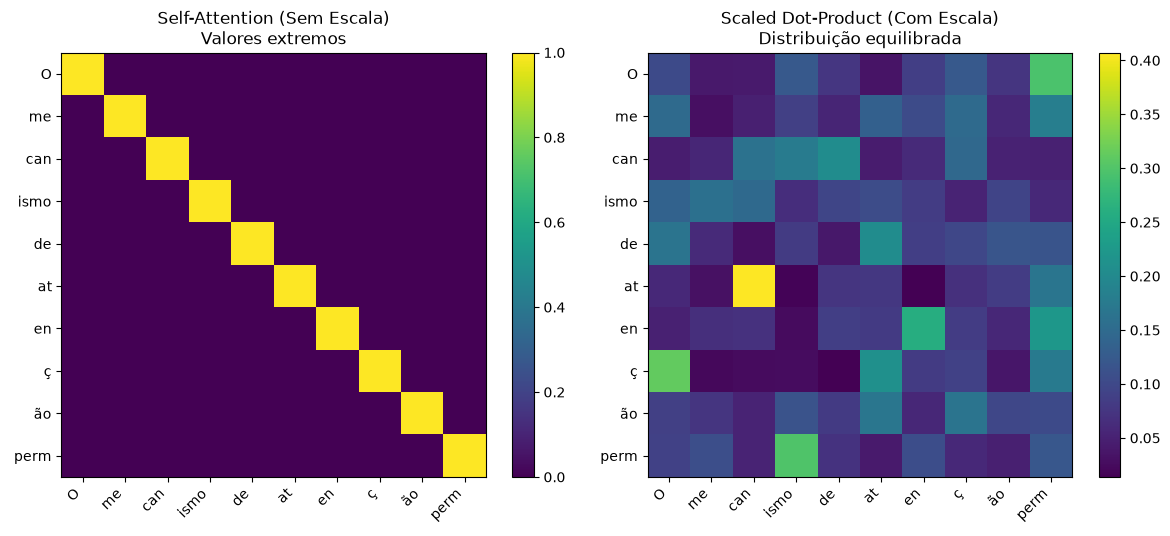

In [8]:
import sys
import torch
import matplotlib.pyplot as plt
import tiktoken
from pathlib import Path

# Configura o caminho para a pasta Codigo
sys.path.append(str(Path.cwd().parent / "Codigo"))

from dataset import create_dataloader_v1
from embeddings import GPTInputEmbeddings
from attention import simple_self_attention, ScaledDotProductAttention

# ============================================================
# 1. Preparação dos Dados (Pipeline Integrado)
# ============================================================
texto = "O mecanismo de atenção permite focar no que importa."
vocab_size = 50257
max_length = 10
d_in = 64

# Cria o DataLoader e extrai um lote
dataloader = create_dataloader_v1(texto, batch_size=1, max_length=max_length, stride=10, drop_last=False)
inputs_ids, targets_ids = next(iter(dataloader))

# Converte IDs em Embeddings
embedding_layer = GPTInputEmbeddings(vocab_size, d_in, max_length)
embeds = embedding_layer(inputs_ids) # Formato: [1, 10, 64]

# Decodifica tokens para o gráfico
tokenizer = tiktoken.get_encoding("gpt2")
tokens_texto = [tokenizer.decode([idx.item()]) for idx in inputs_ids[0]]

# ============================================================
# 2. Experimento: Com e Sem Escala
# ============================================================
# Usamos a primeira sequência do batch
seq_embeds = embeds[0] 

# A. Sem Escala
_, weights_unscaled = simple_self_attention(seq_embeds)

# B. Com Escala
torch.manual_seed(123)
scaled_att = ScaledDotProductAttention(d_in=d_in, d_out=d_in)
_, weights_scaled = scaled_att(seq_embeds)

# ============================================================
# 3. Visualização
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Sem Escala
im1 = axes[0].imshow(weights_unscaled.detach().numpy(), cmap='viridis')
axes[0].set_title("Self-Attention (Sem Escala)\nValores extremos")
axes[0].set_xticks(range(max_length)); axes[0].set_xticklabels(tokens_texto, rotation=45, ha='right')
axes[0].set_yticks(range(max_length)); axes[0].set_yticklabels(tokens_texto)
fig.colorbar(im1, ax=axes[0])

# Plot Com Escala
im2 = axes[1].imshow(weights_scaled.detach().numpy(), cmap='viridis')
axes[1].set_title("Scaled Dot-Product (Com Escala)\nDistribuição equilibrada")
axes[1].set_xticks(range(max_length)); axes[1].set_xticklabels(tokens_texto, rotation=45, ha='right')
axes[1].set_yticks(range(max_length)); axes[1].set_yticklabels(tokens_texto)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

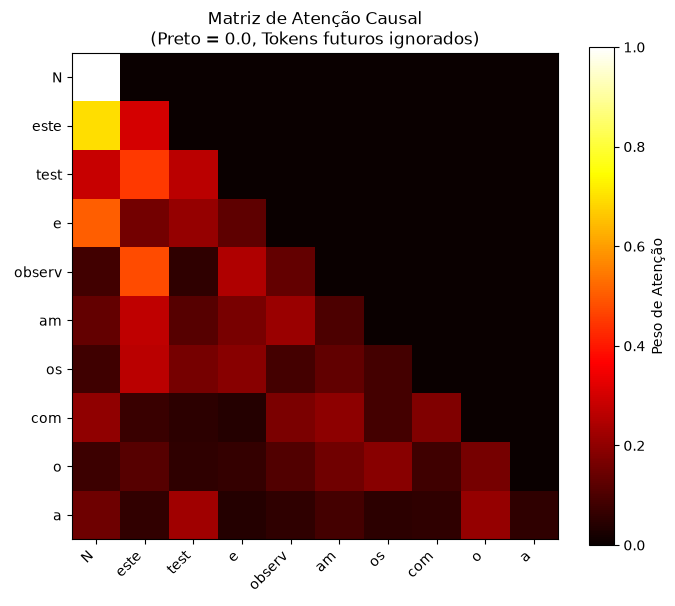

In [9]:
import sys
import torch
import matplotlib.pyplot as plt
import tiktoken
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from dataset import create_dataloader_v1
from embeddings import GPTInputEmbeddings
from attention import CausalAttention

# ============================================================
# 1. Preparação dos Dados
# ============================================================
texto = "Neste teste observamos como a máscara esconde o futuro."
max_length = 10
d_model = 64

dataloader = create_dataloader_v1(texto, batch_size=1, max_length=max_length, stride=10, drop_last=False)
inputs_ids, _ = next(iter(dataloader))

embed_layer = GPTInputEmbeddings(vocab_size=50257, output_dim=d_model, max_length=max_length)
embeds = embed_layer(inputs_ids) # [1, 10, 64]

tokenizer = tiktoken.get_encoding("gpt2")
tokens_texto = [tokenizer.decode([idx.item()]) for idx in inputs_ids[0]]

# ============================================================
# 2. Experimento: Máscara Causal
# ============================================================
torch.manual_seed(123)
causal_att = CausalAttention(d_in=d_model, d_out=d_model, context_length=max_length, dropout=0.0)

# Reconstruindo os passos internos para capturar a matriz de pesos isolada
keys = causal_att.W_key(embeds)
queries = causal_att.W_query(embeds)
attn_scores = queries @ keys.transpose(1, 2)

# Aplicação da Máscara
mask_bool = causal_att.mask.bool()[:max_length, :max_length]
attn_scores.masked_fill_(mask_bool, -torch.inf)
attn_weights_causal = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

# ============================================================
# 3. Visualização
# ============================================================
plt.figure(figsize=(7, 6))
plt.imshow(attn_weights_causal[0].detach().numpy(), cmap='hot')
plt.title("Matriz de Atenção Causal\n(Preto = 0.0, Tokens futuros ignorados)")
plt.xticks(range(max_length), tokens_texto, rotation=45, ha='right')
plt.yticks(range(max_length), tokens_texto)
plt.colorbar(label='Peso de Atenção')
plt.tight_layout()
plt.show()

In [10]:
import sys
import torch
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from dataset import create_dataloader_v1
from embeddings import GPTInputEmbeddings
from attention import ScaledDotProductAttention, MultiHeadAttention

# ============================================================
# 1. Preparação
# ============================================================
texto = "Multi-head attention divide o trabalho em várias partes."
max_length = 8
d_in = 128
d_out = 128 # Mantemos d_out fixo para comparar de forma justa

dataloader = create_dataloader_v1(texto, batch_size=1, max_length=max_length, stride=8, drop_last=False)
inputs_ids, _ = next(iter(dataloader))
embeds = GPTInputEmbeddings(vocab_size=50257, output_dim=d_in, max_length=max_length)(inputs_ids)

print("=" * 60)
print("EXPERIMENTO: Self-Attention vs Multi-Head Attention")
print("=" * 60)
print(f"Tensor de Entrada (Embeddings): {embeds.shape}\n")

# ============================================================
# 2. Self-Attention (Equivale a 1 Head)
# ============================================================
torch.manual_seed(42)
self_att = ScaledDotProductAttention(d_in=d_in, d_out=d_out)
context_self, _ = self_att(embeds[0]) # Envia sem a dimensão de batch
print("1. Self-Attention (Single Head):")
print(f"   Formato de Saída: {context_self.shape}")
print(f"   Dimensão da 'Head' única: {d_out} (Processa tudo de uma vez)\n")

# ============================================================
# 3. Multi-Head (2 Heads)
# ============================================================
num_heads_2 = 2
mha_2 = MultiHeadAttention(d_in=d_in, d_out=d_out, context_length=max_length, dropout=0.0, num_heads=num_heads_2)
context_mha_2 = mha_2(embeds)
print(f"2. Multi-Head Attention ({num_heads_2} Heads):")
print(f"   Formato de Saída (com Batch): {context_mha_2.shape}")
print(f"   Dimensão interna por Head: {mha_2.head_dim} (d_out / {num_heads_2})\n")

# ============================================================
# 4. Multi-Head (4 Heads)
# ============================================================
num_heads_4 = 4
mha_4 = MultiHeadAttention(d_in=d_in, d_out=d_out, context_length=max_length, dropout=0.0, num_heads=num_heads_4)
context_mha_4 = mha_4(embeds)
print(f"3. Multi-Head Attention ({num_heads_4} Heads):")
print(f"   Formato de Saída (com Batch): {context_mha_4.shape}")
print(f"   Dimensão interna por Head: {mha_4.head_dim} (d_out / {num_heads_4})\n")

print("Conclusão: O Multi-Head Attention mantém o formato final igual ao Self-Attention, mas divide a dimensão de processamento interno (head_dim), permitindo paralelizar e focar em diferentes aspectos da sequência simultaneamente.")

EXPERIMENTO: Self-Attention vs Multi-Head Attention
Tensor de Entrada (Embeddings): torch.Size([1, 8, 128])

1. Self-Attention (Single Head):
   Formato de Saída: torch.Size([8, 128])
   Dimensão da 'Head' única: 128 (Processa tudo de uma vez)

2. Multi-Head Attention (2 Heads):
   Formato de Saída (com Batch): torch.Size([1, 8, 128])
   Dimensão interna por Head: 64 (d_out / 2)

3. Multi-Head Attention (4 Heads):
   Formato de Saída (com Batch): torch.Size([1, 8, 128])
   Dimensão interna por Head: 32 (d_out / 4)

Conclusão: O Multi-Head Attention mantém o formato final igual ao Self-Attention, mas divide a dimensão de processamento interno (head_dim), permitindo paralelizar e focar em diferentes aspectos da sequência simultaneamente.


In [11]:
import sys
import torch
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "Codigo"))
from dataset import create_dataloader_v1
from embeddings import GPTInputEmbeddings
from attention import MultiHeadAttention

print("=" * 60)
print("EXPERIMENTO: Diferentes Sequências e Diferentes Embeddings")
print("=" * 60)

# ============================================================
# Cenário A: Frase Curta, Embedding Pequeno
# ============================================================
texto_curto = "Sequência pequena."
max_len_A = 4
d_in_A = 16   # Embedding pequeno
d_out_A = 32  # Projeção final
heads_A = 2

loader_A = create_dataloader_v1(texto_curto, batch_size=1, max_length=max_len_A, stride=4, drop_last=False)
inputs_A, _ = next(iter(loader_A))

embeds_A = GPTInputEmbeddings(vocab_size=50257, output_dim=d_in_A, max_length=max_len_A)(inputs_A)
mha_A = MultiHeadAttention(d_in=d_in_A, d_out=d_out_A, context_length=max_len_A, dropout=0.0, num_heads=heads_A)
saida_A = mha_A(embeds_A)

print("CENÁRIO A (Leve):")
print(f"   Texto Original: '{texto_curto}'")
print(f"   Tamanho Seq (Tokens): {inputs_A.shape[1]}")
print(f"   Dimensão Embedding Entrada: {d_in_A}")
print(f"   Matriz após Attention (Saída): {saida_A.shape}\n")

# ============================================================
# Cenário B: Texto Longo, Embedding Largo (Modelo Maior)
# ============================================================
texto_longo = "O modelo processa textos longos dividindo o vocabulário e mapeando as palavras para vetores de altíssima dimensão estrutural. " * 5
max_len_B = 32
d_in_B = 256  # Embedding largo
d_out_B = 512 # Projeção final
heads_B = 8

loader_B = create_dataloader_v1(texto_longo, batch_size=2, max_length=max_len_B, stride=32, drop_last=False)
inputs_B, _ = next(iter(loader_B)) # Pega um lote de 2 sequências

embeds_B = GPTInputEmbeddings(vocab_size=50257, output_dim=d_in_B, max_length=max_len_B)(inputs_B)
mha_B = MultiHeadAttention(d_in=d_in_B, d_out=d_out_B, context_length=max_len_B, dropout=0.1, num_heads=heads_B)
saida_B = mha_B(embeds_B)

print("CENÁRIO B (Pesado):")
print(f"   Tamanho Lote (Batch): {inputs_B.shape[0]}")
print(f"   Tamanho Seq (Tokens): {inputs_B.shape[1]}")
print(f"   Dimensão Embedding Entrada: {d_in_B}")
print(f"   Matriz após Attention (Saída): {saida_B.shape}\n")

print("Conclusão: A implementação das matrizes de atenção adapta-se automaticamente a sequências curtas/longas e vetores finos/largos sem necessidade de reescrever a arquitetura.")

EXPERIMENTO: Diferentes Sequências e Diferentes Embeddings
CENÁRIO A (Leve):
   Texto Original: 'Sequência pequena.'
   Tamanho Seq (Tokens): 4
   Dimensão Embedding Entrada: 16
   Matriz após Attention (Saída): torch.Size([1, 4, 32])

CENÁRIO B (Pesado):
   Tamanho Lote (Batch): 2
   Tamanho Seq (Tokens): 32
   Dimensão Embedding Entrada: 256
   Matriz após Attention (Saída): torch.Size([2, 32, 512])

Conclusão: A implementação das matrizes de atenção adapta-se automaticamente a sequências curtas/longas e vetores finos/largos sem necessidade de reescrever a arquitetura.
